# Stochastic Nagumo PDE

$du(t,x)= \left( \epsilon u_{xx}(t,x) + u_{xx}(1-u_{xx})(u_{xx}-\alpha) \right)dt + \sigma dW(t,x)$, $x\in [0,20]$, $t\in [0,1]$

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import SPDE
import matplotlib.gridspec as gridspec
import time


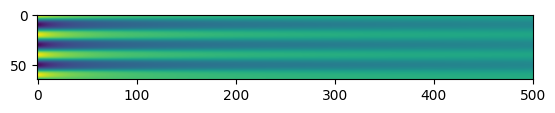

In [2]:
data = scipy.io.loadmat('data/Nagumo_dx_64m_500t.mat')

U = data['sol']
plt.imshow(np.mean(U,2))

In [3]:
dx = 20/(U.shape[0]-1)
dt = 1/(U.shape[1]-1)

Dictt = []
for i in range(U.shape[2]):
    if i%100==0:
        print(i)
    U_t,Di,description = SPDE.build_linear_system(U[:,:-1,i], dt, dx, D = 6, P = 4 )
    Dictt.append(Di)
    
Dictt = np.mean(np.array(Dictt),axis=0)


0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


In [4]:
description

['',
 'u',
 'u^2',
 'u^3',
 'u^4',
 'u_{x}',
 'uu_{x}',
 'u^2u_{x}',
 'u^3u_{x}',
 'u^4u_{x}',
 'u_{xx}',
 'uu_{xx}',
 'u^2u_{xx}',
 'u^3u_{xx}',
 'u^4u_{xx}',
 'u_{xxx}',
 'uu_{xxx}',
 'u^2u_{xxx}',
 'u^3u_{xxx}',
 'u^4u_{xxx}',
 'u_{xxxx}',
 'uu_{xxxx}',
 'u^2u_{xxxx}',
 'u^3u_{xxxx}',
 'u^4u_{xxxx}',
 'u_{xxxxx}',
 'uu_{xxxxx}',
 'u^2u_{xxxxx}',
 'u^3u_{xxxxx}',
 'u^4u_{xxxxx}',
 'u_{xxxxxx}',
 'uu_{xxxxxx}',
 'u^2u_{xxxxxx}',
 'u^3u_{xxxxxx}',
 'u^4u_{xxxxxx}']

# Drift Identification

## LASSO

In [5]:
xdt = data['xdt'].reshape(-1,order='F')
np.random.seed(11)
dxdt = xdt.reshape(1,-1)

start_time = time.time()
lam = 0.2 
Xi_drift = SPDE.Lasso(Dictt,dxdt,lam)

end_time = time.time()
print("Elapsed time: ",end_time-start_time)


Elapsed time:  1.997093915939331


In [6]:
Xi_act = [ 0.,  0.5,  0.5, -1,  0.,0.,  0.,  0.,  0.,  0.,1, 0.,  0.,  0., 0.,0.,  0.,  0.,  0.,
          0.,0.,  0.,  0.,  0.,  0.,0.,  0.,  0.,  0.,  0.,0.,  0.,  0.,  0.,  0.]

l2_error_sindy = np.linalg.norm(Xi_act-Xi_drift.reshape(-1))
print('L2 error for sindy:   ', l2_error_sindy)

corr_ind = []
for i in range(len(Xi_act)):
    if Xi_act[i] !=0:
        corr_ind.append(i)
fp_sindy=0
for i in range(len(Xi_act)):
    if i in corr_ind:
        pass
    else:
        if Xi_drift[i] != 0:
            fp_sindy+=1
            
fpr_sindy = (fp_sindy/len(Xi_act))*100
print('False Positive Rate for Sindy (%):   ',fpr_sindy)

L2 error for sindy:    0.1949645492837313
False Positive Rate for Sindy (%):    88.57142857142857


## SINDy

In [7]:
xdt = data['xdt'].reshape(-1,order='F')
np.random.seed(11)
dxdt = xdt.reshape(1,-1)

start_time = time.time()
lam = 0.3
Xi_drift = SPDE.sindy(lam,Dictt,dxdt)

end_time = time.time()
print("Elapsed time: ",end_time-start_time)

theta1 = np.zeros(16)
Xi_drift

Elapsed time:  0.08810210227966309


array([[ 0.        ],
       [ 0.52160195],
       [ 0.49923389],
       [-0.99796889],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 1.02055813],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [ 0.        ]])

In [8]:
Xi_act = [ 0.,  0.5,  0.5, -1,  0.,0.,  0.,  0.,  0.,  0.,1, 0.,  0.,  0., 0.,0.,  0.,  0.,  0.,
          0.,0.,  0.,  0.,  0.,  0.,0.,  0.,  0.,  0.,  0.,0.,  0.,  0.,  0.,  0.]

In [9]:
l2_error_sindy = np.linalg.norm(Xi_act-Xi_drift.reshape(-1))
print('L2 error for sindy:   ', l2_error_sindy)

L2 error for sindy:    0.02989971944341792


In [10]:
corr_ind = []
for i in range(len(Xi_act)):
    if Xi_act[i] !=0:
        corr_ind.append(i)
fp_sindy=0
for i in range(len(Xi_act)):
    if i in corr_ind:
        pass
    else:
        if Xi_drift[i] != 0:
            fp_sindy+=1
fpr_sindy = (fp_sindy/len(Xi_act))*100
print('False Positive Rate for Sindy (%):   ',fpr_sindy)



False Positive Rate for Sindy (%):    0.0


## Variational Bayes

In [11]:
for i in range(len(Xi_drift)):
    if Xi_drift[i] != 0:
        Xi_drift[i] =1
initz = Xi_drift.reshape(-1)

In [12]:
X = Dictt
y = xdt.reshape(-1)
initz0 = initz.reshape(-1)
tol = 1e-8
verbosity = True

start_time = time.time()
DS1 = SPDE.Variational_Bayes_Code(X, y, initz0, tol, verbosity)

end_time = time.time()
print("Elapsed time: ",end_time-start_time)

# neglecting the small coefficients whose value is less than 0.01
for i in range((len(Xi_drift))):
    if abs(DS1['wmean'][i])<= 0.025:
        DS1['zmean'][i]=0
        DS1['wmean'][i]=0
        
DS1["wmean"]

c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\Nagumo\SPDE.py:441: RuntimeWarning: overflow encountered in exp
  expitC = 1.0 / (1 + np.exp(-C))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\Nagumo\SPDE.py:410: RuntimeWarning: divide by zero encountered in log
  + np.nansum(zm * (np.log(p0) - np.log(zm)))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\Nagumo\SPDE.py:410: RuntimeWarning: invalid value encountered in multiply
  + np.nansum(zm * (np.log(p0) - np.log(zm)))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\Nagumo\SPDE.py:411: RuntimeWarning: divide by zero encountered in log
  + np.nansum((1 - zm) * (np.log(1 - p0) - np.log(1 - zm)))
c:\Users\bluem\OneDrive\Documents\University\Masters\Modules\Project\Programming\Stochastic-PDE-Discovery\Nagumo

Iteration = 0  log(Likelihood) = -28918.877006583236
Iteration = 1  log(Likelihood) = -28834.593483553665
Iteration = 2  log(Likelihood) = -28834.59347349124
Iteration = 3  log(Likelihood) = -28834.5934734918
OOPS!  log(like) decreasing!!
Iteration = 4  log(Likelihood) = -28834.593473491317
Elapsed time:  2.027817964553833


array([ 0.        ,  0.52407677,  0.50047542, -0.9981566 ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.0222022 ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [13]:
DS1['zmean']

array([0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [14]:
np.diag(DS1['wCOV'])

array([1.81320916e-05, 5.54929158e-05, 4.41391103e-06, 9.86033147e-07,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 2.83887380e-05, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00, 3.34872794e+00,
       3.34872794e+00, 3.34872794e+00, 3.34872794e+00])

In [15]:
np.diag(DS1['wCOV'])[np.where(DS1['zmean'] == 1)]

array([5.54929158e-05, 4.41391103e-06, 9.86033147e-07, 2.83887380e-05])

In [16]:
l2_error_vb = np.linalg.norm(Xi_act-DS1['wmean'])
print('L2 error for sindy:   ', l2_error_vb)

L2 error for sindy:    0.03280628595900673


In [17]:
fp_vb=0
for i in range(len(Xi_act)):
    if i in corr_ind:
        pass
    else:
        if DS1['wmean'][i] != 0:
            fp_vb+=1
fpr_vb = (fp_vb/len(Xi_act))*100
print('False Positive Rate for VB (%):   ',fpr_vb)

False Positive Rate for VB (%):    0.0


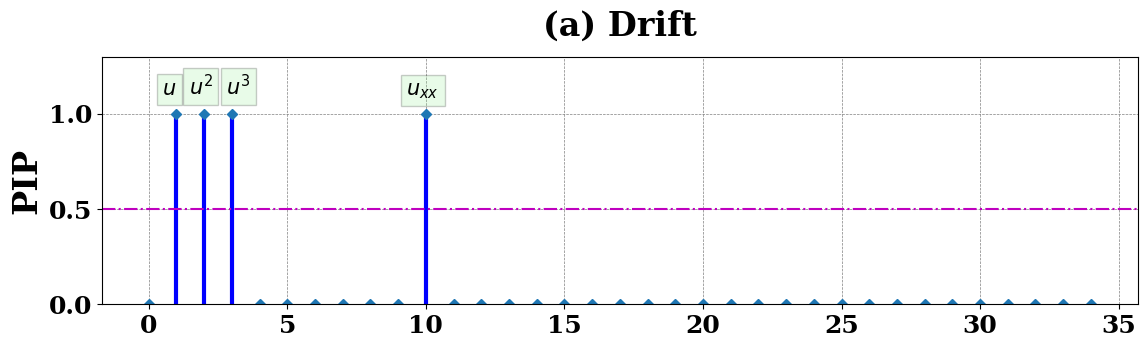

In [18]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 24

figure1=plt.figure(figsize = (12, 4))
xr = np.array(range(len(Xi_drift)))
# plt.stem(xr,DS1['zmean'], markerfmt='C0D', linefmt='lightblue', basefmt="k")
plt.vlines(xr, 0, DS1['zmean'], colors='blue', linewidth=3.0)
plt.plot(xr, DS1['zmean'], 'C0D', markersize=5)
plt.axhline(y= 0.5, color='m', linestyle='-.')
# plt.xlabel('Basis functions', fontweight='bold', fontsize=24)
plt.ylabel('PIP', fontweight='bold', fontsize=24);
plt.title('(a) Drift', fontweight='bold', fontsize=24, pad=15)
plt.grid(color='gray', linestyle='--', linewidth=0.5); plt.ylim(0,1.3)
plt.xticks(fontweight='bold', fontsize=18); plt.yticks(fontweight='bold', fontsize=18);
plt.text(1.0, 1.1, "$u$", bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=15, ha='right')
plt.text(1.44, 1.1, "$u^2$", bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=15)
plt.text(2.8, 1.1, "$u^3$", bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=15)
plt.text(9.3, 1.1, "$u_{xx}$", bbox=dict(facecolor='lightgreen', alpha=0.2), fontsize=15)
plt.tight_layout()


# Diffusion Identification

## LASSO

In [45]:
target = np.zeros(35)#hardcoded
target[0] = 1


xdts = data['xdiff'].reshape(-1,order='F')
np.random.seed(1)
dxdt = xdts.reshape(1,-1)

start_time = time.time()
lam = 0.1 
Xi_diff = SPDE.Lasso(Dictt,dxdt,lam)
print("Diffusion terms (Lasso): ", Xi_diff)

end_time = time.time()
print("Elapsed time: ",end_time-start_time)

theta1 = np.zeros(16)

l2_error_lasso = np.linalg.norm(Xi_diff.reshape(-1)-target)
print("L2 Error Lasso: (diffusion): ", l2_error_lasso)

Diffusion terms (Lasso):  [ 1.03264348e+00+0.j  6.97514200e-02+0.j -2.03483272e-01+0.j
  8.69913136e-02+0.j -3.53529339e-03+0.j -8.54088537e-08+0.j
  1.50443118e-03+0.j  1.08886754e-04+0.j  1.67207198e-05+0.j
 -5.50141756e-05+0.j  3.63265411e-02+0.j -8.99333870e-02+0.j
  1.16030067e-01+0.j -4.80878785e-02+0.j  2.00674690e-03+0.j
  3.28045294e-03+0.j  1.37352613e-03+0.j -1.27839464e-03+0.j
 -2.99377256e-04+0.j -4.29794089e-05+0.j  5.24016048e-03+0.j
 -1.69826067e-02+0.j  1.80041717e-02+0.j -6.52337922e-03+0.j
  6.75064725e-04+0.j  3.97540926e-04+0.j  2.75523295e-04+0.j
 -1.77791613e-04+0.j -3.74591661e-05+0.j  7.83901254e-06+0.j
 -1.91895525e-04+0.j -2.44728379e-04+0.j  5.80798852e-04+0.j
 -2.94615921e-04+0.j  4.35894435e-05+0.j]
Elapsed time:  1.8065662384033203
L2 Error Lasso: (diffusion):  0.28426015530086207


## SINDy

In [46]:
xdts = data['xdiff'].reshape(-1,order='F')
np.random.seed(1)

dxdt1 = xdts.reshape(1,-1)

start_time = time.time()
lam = 0.5 
Xi_diff = SPDE.sindy(lam,Dictt,dxdt1)
print("Diffusion terms (Stochastic SINDy): ", Xi_diff)

end_time = time.time()
print("Elapsed time: ",end_time-start_time)

theta1 = np.zeros(16)
Xi_diff
l2_error_lasso = np.linalg.norm(Xi_diff.reshape(-1)-target)
print("L2 Error SINDy: (diffusion): ", l2_error_lasso)

Diffusion terms (Stochastic SINDy):  [[1.04039724]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]
Elapsed time:  0.0715329647064209
L2 Error SINDy: (diffusion):  0.04039724016868118


## Variational Bayes

In [ ]:
for i in range(len(Xi_drift)): #might be wrong...
    if Xi_diff[i] != 0:
        Xi_diff[i] =1
initz2 = Xi_diff.reshape(-1)

In [22]:
X = Dictt
y = xdts.reshape(-1)
initz0 = initz2.reshape(-1)
tol = 0.000001
verbosity = True

start_time = time.time()
DS2 = SPDE.Variational_Bayes_Code(X, y, initz0, tol, verbosity)

end_time = time.time()
print("Elapsed time: ",end_time-start_time)

# neglecting the small coefficients whose value is less than 0.01
for i in range((len(Xi_diff))):
    if abs(DS2['wmean'][i])<= 0.01:
        DS2['zmean'][i]=0
        DS2['wmean'][i]=0
np.sqrt(DS2["wmean"])

Iteration = 0  log(Likelihood) = -13546.699137187492
Iteration = 1  log(Likelihood) = -13478.457067413538
Iteration = 2  log(Likelihood) = -13478.457057442482
Iteration = 3  log(Likelihood) = -13478.457057442516
OOPS!  log(like) decreasing!!
Iteration = 4  log(Likelihood) = -13478.457057442438
Elapsed time:  1.9809975624084473


array([1.01999708, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

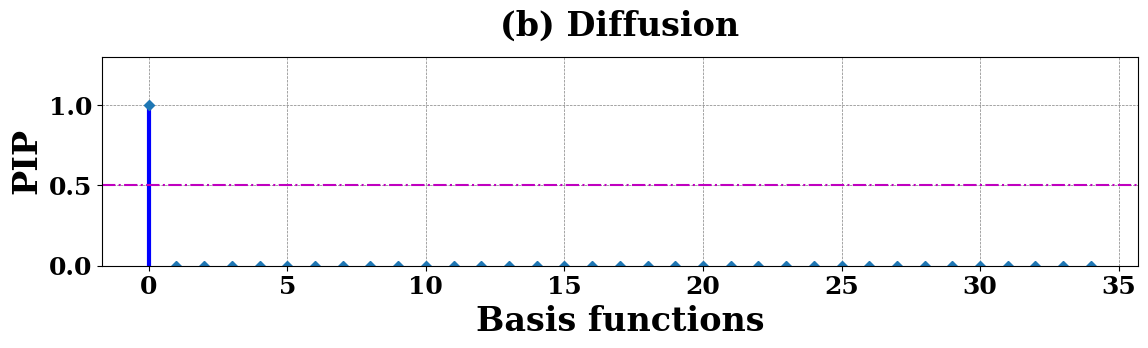

In [23]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 24

figure1=plt.figure(figsize = (12, 4))
xr = np.array(range(len(Xi_drift)))
plt.vlines(xr, 0, DS2['zmean'], colors='blue', linewidth=3.0)
plt.plot(xr, DS2['zmean'], 'C0D', markersize=5)

plt.axhline(y= 0.5, color='m', linestyle='-.')
plt.xlabel('Basis functions', fontweight='bold', fontsize=24)
plt.ylabel('PIP', fontweight='bold', fontsize=24);
plt.title('(b) Diffusion', fontweight='bold', fontsize=24, pad=15)
plt.grid(color='gray', linestyle='--', linewidth=0.5); plt.ylim(0,1.3)
plt.xticks(fontweight='bold', fontsize=18); plt.yticks(fontweight='bold', fontsize=18);

plt.tight_layout()


In [24]:
np.diag(DS2['wCOV'])

array([4.10141646e-06, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00, 1.33296445e+00,
       1.33296445e+00, 1.33296445e+00, 1.33296445e+00])

In [25]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.size'] = 24
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [26]:
from matplotlib.patches import Rectangle

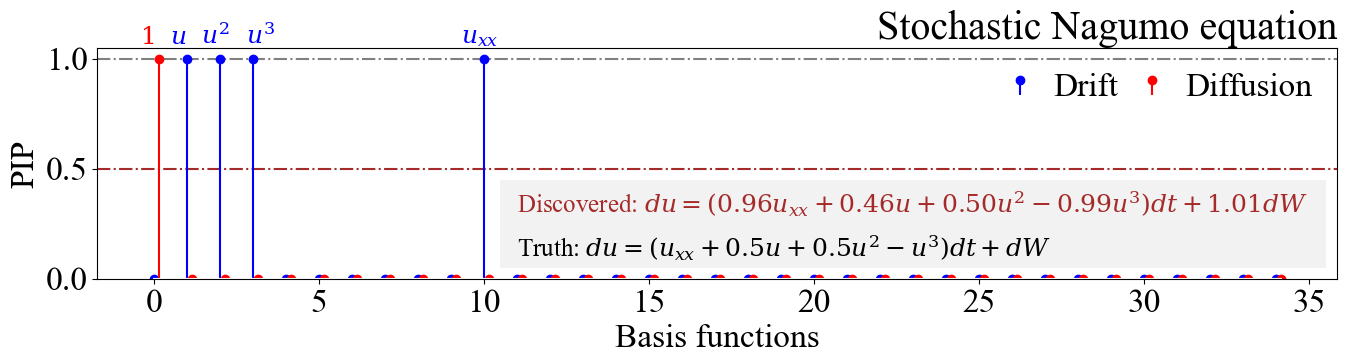

In [27]:
fig, ax = plt.subplots(figsize=(16,3))

xr = np.array(range(len(Xi_drift)))
ax.axhline(y= 1.0, color='grey', linestyle='-.')
ax.axhline(y= 0.5, color='brown', linestyle='-.')
ax.stem(xr, DS1['zmean'], linefmt='b', markerfmt='ob', basefmt='w', label='Drift')
ax.stem(xr+0.15, DS2['zmean'], linefmt='r', markerfmt='or', basefmt='w', label='Diffusion')
ax.set_ylabel('PIP')
ax.set_xlabel('Basis functions')
ax.set_title('Stochastic Nagumo equation', loc='right')
ax.legend(ncol=2, borderpad=0.25, frameon=False, columnspacing=0.01, handletextpad=0.01)
ax.set_ylim(0,1.05)
ax.set_xticks([0,5,10,15,20,25,30,35])
ax.text(1.0, 1.07, "$u$", color='b', fontsize=18, ha='right')
ax.text(1.44, 1.07, "$u^2$", color='b', fontsize=18)
ax.text(2.8, 1.07, "$u^3$", color='b', fontsize=18)
ax.text(9.3, 1.07, "$u_{xx}$", color='b', fontsize=18)
ax.text(0, 1.07, "$1$", color='r', fontsize=18, ha='right')

ax.add_patch(Rectangle((10.5, 0.05), 25, 0.4, facecolor='grey', alpha=0.10))
ax.text(11,0.10, "Truth: $du = (u_{xx}+0.5u+0.5u^2-u^3)dt + dW$", color='k', fontsize=18)
ax.text(11,0.30, "Discovered: $du = (0.96u_{xx}+0.46u+0.50u^2-0.99u^3)dt + 1.01dW$", color='brown', fontsize=18)
plt.show()

fig.savefig('images/Nagumo_identification.pdf',format='pdf', dpi=600, bbox_inches='tight')


# Predictions

In [28]:
U3 = scipy.io.loadmat('data/Nagumo_prediction.mat')['sol_true']
U4 = scipy.io.loadmat('data/Nagumo_prediction.mat')['sol_pred']


In [29]:
arr=np.mean(U3,axis=2)[32,:]
arr1=np.mean(U4,axis=2)[32,:]

In [30]:
plt.rcParams['font.size'] = 16

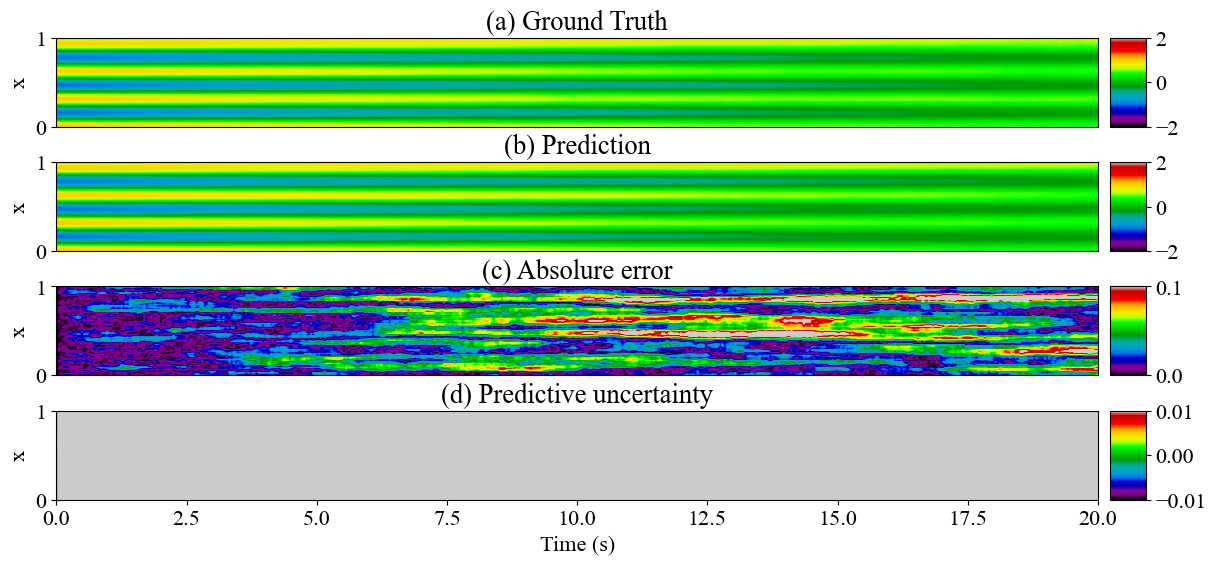

In [31]:
fig = plt.figure(figsize=(16,6))
fig.subplots_adjust(wspace=1,hspace=0.4)
color = 'nipy_spectral'

plt.subplot(4,1,1)
uu = np.mean(U3,axis=2)
plt.imshow(uu, cmap=color, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
plt.ylabel('x');
plt.title('(a) Ground Truth')
plt.xticks([], [])
plt.colorbar(aspect=2.5, pad=0.01)

plt.subplot(4,1,2)
uu1 = np.mean(U4,axis=2)
plt.imshow(uu1, cmap=color, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-2, vmax=2)
plt.ylabel('x');
plt.title('(b) Prediction')
plt.xticks([], [])
plt.colorbar(aspect=2.5, pad=0.01)

plt.subplot(4,1,3)
plt.imshow(np.abs(uu-uu1), cmap=color, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=0, vmax=0.1)
plt.ylabel('x');
plt.title('(c) Absolure error')
plt.xticks([], [])
plt.colorbar(aspect=2.5, pad=0.01)

plt.subplot(4,1,4)
plt.imshow(np.std(U4,axis=2), cmap=color, aspect='auto', origin='lower', extent=[0, 20, 0, 1], vmin=-0.01, vmax=0.01)
plt.xlabel('Time (s)')
plt.ylabel('x');
plt.title('(d) Predictive uncertainty')
plt.colorbar(aspect=2.5, pad=0.01)

plt.show()

fig.savefig('images/Nagumo_prediction.pdf',format='pdf', dpi=300, bbox_inches='tight')
